# ML Alpha Prediction: Feature Matrix → Ridge → XGBoost → SHAP

**Mục tiêu:**
1. Build feature matrix (cross-sectional rank mỗi ngày) — module `src/feature_engineering.py`
2. Label: forward return N ngày (regression), có tùy chọn classification (top/bottom quintile)
3. Baseline: Linear/Ridge trước → XGBoost sau, Purged K-Fold CV bắt buộc
4. **SHAP values**: `shap.TreeExplainer` trên XGBoost, so sánh với feature importance thông thường
5. Đánh giá bằng IC của prediction (không chỉ RMSE)

Đây là Phần 1 của Mini Project `05_ml_alpha_prediction.ipynb`.


In [1]:
# -*- coding: utf-8 -*-
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import VN30_UNIVERSE, load_ohlcv, filter_by_coverage
from src.momentum_factors import momentum_6_1, momentum_12_1
from src.feature_engineering import assemble_dataset, cross_sectional_rank
from src.ic_analysis import single_factor_ic, composite_score_ic
from src.strategy import normalize_ic_weights
from src.model import (
    fit_linear_baseline, fit_ridge, fit_xgboost,
    purged_kfold_oos_predictions, evaluate_oos_predictions,
    compute_shap_values, shap_importance_ranking, compare_importance_methods,
)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 1. Tải dữ liệu + Momentum factors (tái sử dụng Ngày 18)

In [2]:
START, END = "2022-01-01", "2025-12-31"

ohlcv = load_ohlcv(VN30_UNIVERSE, START, END, fields=("close", "open", "volume"))
price_df, volume_df = ohlcv["close"], ohlcv["volume"]
price_df, dropped = filter_by_coverage(price_df)
volume_df = volume_df[price_df.columns]
print(f"Universe: {len(price_df.columns)} mã (loại {dropped})")


[1/30] Loading ACB...


[2/30] Loading BID...
[3/30] Loading BSR...
[4/30] Loading CTG...
[5/30] Loading FPT...
[6/30] Loading GAS...
[7/30] Loading GVR...
[8/30] Loading HDB...
[9/30] Loading HPG...
[10/30] Loading LPB...
[11/30] Loading MBB...
[12/30] Loading MCH...


[13/30] Loading MSN...
[14/30] Loading MWG...
[15/30] Loading SAB...
[16/30] Loading SHB...
[17/30] Loading SSB...
[18/30] Loading SSI...
⏳ Nghỉ 65s để tránh rate limit...
[19/30] Loading STB...
[20/30] Loading TCB...
[21/30] Loading TCX...
[22/30] Loading VCB...
[23/30] Loading VHM...
[24/30] Loading VIB...
[25/30] Loading VIC...
[26/30] Loading VJC...
[27/30] Loading VNM...
[28/30] Loading VPB...
[29/30] Loading VPL...
[30/30] Loading VRE...

✅ Đã tải: 30/30 mã
Universe: 28 mã (loại ['TCX', 'VPL'])


## 2. Build Feature Matrix (30+ features mục tiêu)

Ở Phần 1 này, ta bắt đầu với bộ factor cơ bản đã có (momentum + volume + volatility)
và cross-sectional rank mỗi factor — module `feature_engineering.py` xử lý toàn bộ
logic rank + ghép MultiIndex (date, symbol), KHÔNG viết lại hàm trong notebook.

Mở rộng lên 30+ feature (thêm biến thể lookback, sector dummies, v.v.) là bước
tiếp theo ở Ngày 25-26 — notebook này tập trung đúng yêu cầu Ngày 19: pipeline
hoàn chỉnh Ridge → XGBoost → SHAP trước khi mở rộng feature set.

In [3]:
returns_df = price_df.pct_change(fill_method=None)
vol_20 = returns_df.rolling(20).std()
vol_120 = returns_df.rolling(120).std()

raw_factors = {
    "Momentum_6_1": momentum_6_1(price_df),
    "Momentum_12_1": momentum_12_1(price_df),
    "Volume_Ratio": volume_df / volume_df.rolling(20).mean(),
    "Vol_Ratio_20_120": vol_20 / vol_120,
}

FEATURE_COLS = list(raw_factors.keys())
print(f"Số feature: {len(FEATURE_COLS)} — {FEATURE_COLS}")


Số feature: 4 — ['Momentum_6_1', 'Momentum_12_1', 'Volume_Ratio', 'Vol_Ratio_20_120']


### 2.1 Label: forward return 5 ngày (regression) — cân nhắc classification nếu quá noisy

In [4]:
N_FWD = 5
dataset_reg = assemble_dataset(raw_factors, price_df, n_fwd=N_FWD, label_type="regression")
print(f"Dataset (regression): {dataset_reg.shape}")
print(f"Khoảng: {dataset_reg.index.get_level_values('date').min().date()} "
      f"→ {dataset_reg.index.get_level_values('date').max().date()}")
dataset_reg.head()


Dataset (regression): (20571, 5)
Khoảng: 2023-01-06 → 2025-12-24


Momentum_6_1  Momentum_12_1  Volume_Ratio  \
date                symbol                                              
2023-01-06 07:00:00 ACB           0.6071         0.6786        0.7857   
                    BID           0.8929         0.9286        0.9643   
                    BSR           0.0357         0.2500        0.8929   
                    CTG           0.7500         0.6429        0.9286   
                    FPT           0.5714         0.8929        0.3929   

                            Vol_Ratio_20_120  fwd_return  
date                symbol                                
2023-01-06 07:00:00 ACB               0.1786      0.0427  
                    BID               0.4286      0.0036  
                    BSR               0.2857      0.0276  
                    CTG               0.2500      0.0174  
                    FPT               0.3214     -0.0036

In [5]:
# Kiểm tra label có quá noisy không: std của fwd_return so với mean
label_stats = dataset_reg["fwd_return"].describe()
print(label_stats)
noise_ratio = label_stats["std"] / abs(label_stats["mean"]) if label_stats["mean"] != 0 else np.inf
print(f"\nStd/|Mean| ratio: {noise_ratio:.1f}x — càng cao label càng noisy")
print("Nếu ratio quá cao (>>10x, phổ biến với return 5 ngày), cân nhắc dùng")
print("classification (top/bottom quintile) thay vì regression thuần.")


count   20571.0000
mean        0.0051
std         0.0424
min        -0.2481
25%        -0.0173
50%         0.0022
75%         0.0246
max         0.3355
Name: fwd_return, dtype: float64

Std/|Mean| ratio: 8.3x — càng cao label càng noisy
Nếu ratio quá cao (>>10x, phổ biến với return 5 ngày), cân nhắc dùng
classification (top/bottom quintile) thay vì regression thuần.


In [6]:
# Bản classification thay thế (dự phòng nếu regression quá noisy)
dataset_clf = assemble_dataset(
    raw_factors, price_df, n_fwd=N_FWD, label_type="classification",
    top_pct=0.3, bottom_pct=0.3,
)
print(f"Dataset (classification): {dataset_clf.shape}")
print(f"Label distribution:\n{dataset_clf['label_class'].value_counts()}")


Dataset (classification): (13201, 5)
Label distribution:
label_class
1.0000    6617
0.0000    6584
Name: count, dtype: int64


## 3. Baseline: Linear Regression → Ridge (đơn giản, dễ diagnose trước)

Linear Regression thuần dùng để diagnose overfitting: so sánh coefficient với
Ridge để xem regularization thay đổi gì (Ridge co hệ số về gần 0 nếu feature
không ổn định / đa cộng tuyến).

In [7]:
X_all, y_all = dataset_reg[FEATURE_COLS], dataset_reg["fwd_return"]

linear_full = fit_linear_baseline(X_all, y_all)
ridge_full = fit_ridge(X_all, y_all, alpha=1.0)

print("=== Coefficients: Linear vs Ridge (full sample, chỉ để diagnose) ===")
coef_df = pd.DataFrame({
    "Linear": linear_full.coef_, "Ridge (alpha=1.0)": ridge_full.coef_,
}, index=FEATURE_COLS)
print(coef_df)


=== Coefficients: Linear vs Ridge (full sample, chỉ để diagnose) ===
                  Linear  Ridge (alpha=1.0)
Momentum_6_1      0.0045             0.0045
Momentum_12_1     0.0018             0.0018
Volume_Ratio      0.0032             0.0032
Vol_Ratio_20_120  0.0042             0.0042


### 3.1 Purged K-Fold OOS — Ridge

In [8]:
oos_ridge = purged_kfold_oos_predictions(
    dataset_reg, FEATURE_COLS, model_fn=fit_ridge, n_splits=5, embargo=5, alpha=1.0,
)
ridge_eval = evaluate_oos_predictions(oos_ridge)
print("=== Ridge OOS Evaluation (Purged K-Fold) ===")
for k, v in ridge_eval.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


=== Ridge OOS Evaluation (Purged K-Fold) ===
  Mean IC: 0.0172
  Std IC: 0.2686
  IC-IR: 0.0639
  IC>0 (%): 0.5162
  RMSE: 0.0424
  N days: 740


## 4. XGBoost — capture non-linearity + interaction

In [9]:
oos_xgb = purged_kfold_oos_predictions(
    dataset_reg, FEATURE_COLS, model_fn=fit_xgboost, n_splits=5, embargo=5,
    n_estimators=200, max_depth=3, learning_rate=0.05,
)
xgb_eval = evaluate_oos_predictions(oos_xgb)
print("=== XGBoost OOS Evaluation (Purged K-Fold) ===")
for k, v in xgb_eval.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print("\n=== So sánh Ridge vs XGBoost (IC, không chỉ RMSE) ===")
compare_df = pd.DataFrame({"Ridge": ridge_eval, "XGBoost": xgb_eval}).T
print(compare_df[["Mean IC", "IC-IR", "IC>0 (%)", "RMSE"]])


=== XGBoost OOS Evaluation (Purged K-Fold) ===
  Mean IC: 0.0377
  Std IC: 0.2150
  IC-IR: 0.1754
  IC>0 (%): 0.5649
  RMSE: 0.0426
  N days: 740

=== So sánh Ridge vs XGBoost (IC, không chỉ RMSE) ===
         Mean IC  IC-IR  IC>0 (%)   RMSE
Ridge     0.0172 0.0639    0.5162 0.0424
XGBoost   0.0377 0.1754    0.5649 0.0426


## 5. SHAP Values — xác nhận feature nào THỰC SỰ drive prediction

`shap.TreeExplainer` phân bổ đóng góp công bằng theo Shapley values (game theory),
khác với `feature_importances_` chuẩn của XGBoost (đo "số lần dùng để split"
hoặc "gain trung bình") — feature importance chuẩn có thể SAI khi các feature
tương quan cao (một feature "che" đóng góp thật của feature khác).

In [10]:
xgb_final = fit_xgboost(X_all, y_all, n_estimators=200, max_depth=3, learning_rate=0.05)
explainer, shap_values = compute_shap_values(xgb_final, X_all)

print(f"SHAP values shape: {shap_values.shape} (n_obs x n_features)")


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


SHAP values shape: (20571, 4) (n_obs x n_features)


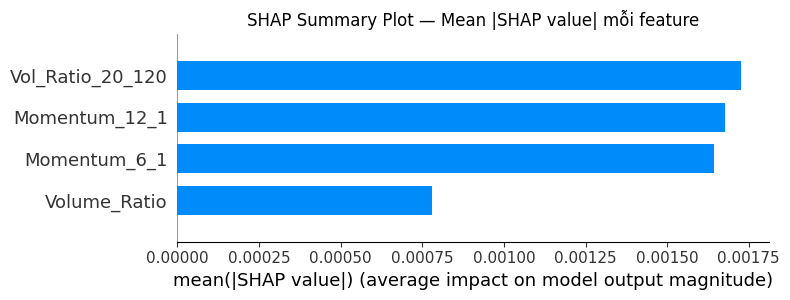

✅ Đã lưu: reports/day19_shap_summary_bar.png


In [11]:
import shap

# Summary plot (bar) — mean |SHAP| mỗi feature
shap.summary_plot(shap_values, X_all, plot_type="bar", show=False)
plt.title("SHAP Summary Plot — Mean |SHAP value| mỗi feature")
plt.tight_layout()
plt.savefig("../reports/day19_shap_summary_bar.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Đã lưu: reports/day19_shap_summary_bar.png")


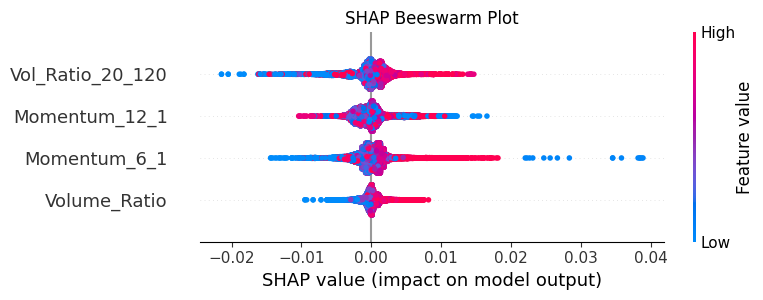

✅ Đã lưu: reports/day19_shap_beeswarm.png


In [12]:
# Beeswarm plot — phân phối SHAP value từng feature, có màu theo giá trị feature gốc
shap.summary_plot(shap_values, X_all, show=False)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.savefig("../reports/day19_shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Đã lưu: reports/day19_shap_beeswarm.png")


### 5.1 So sánh SHAP importance vs XGBoost feature_importances_ thông thường

In [13]:
cmp_importance = compare_importance_methods(xgb_final, FEATURE_COLS, shap_values)
print(cmp_importance)

print("\nRank khác nhau đáng kể (rank_diff > 0) là dấu hiệu multicollinearity")
print("giữa các feature — feature importance chuẩn có thể đánh giá SAI mức độ")
print("đóng góp thật của từng feature khi chúng tương quan với nhau.")


                  xgb_importance  shap_importance  xgb_rank  shap_rank  \
Vol_Ratio_20_120          0.2637           0.0017         2          1   
Momentum_12_1             0.2476           0.0017         3          2   
Momentum_6_1              0.2917           0.0016         1          3   
Volume_Ratio              0.1971           0.0008         4          4   

                  rank_diff  
Vol_Ratio_20_120          1  
Momentum_12_1             1  
Momentum_6_1              2  
Volume_Ratio              0  

Rank khác nhau đáng kể (rank_diff > 0) là dấu hiệu multicollinearity
giữa các feature — feature importance chuẩn có thể đánh giá SAI mức độ
đóng góp thật của từng feature khi chúng tương quan với nhau.


## 6. Đánh giá tổng hợp — IC (không chỉ RMSE), CÓ IC-Weighted Composite

RMSE đo sai số GIÁ TRỊ dự đoán, nhưng cho long-only quintile strategy, điều
quan trọng là dự đoán ĐÚNG THỨ TỰ tương đối giữa các mã (mã nào tốt hơn mã
nào), không phải giá trị return chính xác — đây là lý do IC quan trọng hơn
RMSE cho việc đánh giá factor/model dùng để xây portfolio.

⚠️ **Bổ sung quan trọng**: `launcher.py` (production) dùng **IC-Weighted
composite** (`src/strategy.py::composite_score`), KHÔNG dùng Ridge/XGBoost —
xem lý do ở phần so sánh dưới đây. So sánh trước đây chỉ đối chiếu
best-single-factor vs Ridge/XGBoost, THIẾU phép so sánh trực tiếp với
IC-Weighted — bổ sung ở đây để có bức tranh đầy đủ và công bằng.

In [14]:
# So sánh IC của: best single factor / IC-Weighted composite / Ridge / XGBoost
sf_ic = single_factor_ic(dataset_reg, FEATURE_COLS, n_splits=5, embargo=5)
best_single_factor_ic = sf_ic.abs().max()
best_single_factor_name = sf_ic.abs().idxmax()

# IC-Weighted composite — CHÍNH LÀ signal dùng trong launcher.py (production)
ic_weights = normalize_ic_weights(sf_ic)
composite_eval = composite_score_ic(dataset_reg, FEATURE_COLS, ic_weights, n_splits=5, embargo=5)

print("=== SO SÁNH CUỐI: Best Single Factor vs IC-Weighted vs Ridge vs XGBoost ===")
summary = pd.DataFrame({
    "Method": [
        f"Best single factor ({best_single_factor_name})",
        "IC-Weighted composite (dùng trong launcher.py)",
        "Ridge (all features)", "XGBoost (all features)",
    ],
    "Mean IC": [sf_ic[best_single_factor_name], composite_eval["Mean IC"], ridge_eval["Mean IC"], xgb_eval["Mean IC"]],
    "IC-IR": [np.nan, composite_eval["IC-IR"], ridge_eval["IC-IR"], xgb_eval["IC-IR"]],
})
print(summary.to_string(index=False))

best_method_idx = summary["Mean IC"].idxmax()
print(f"\nPhương pháp có Mean IC cao nhất: {summary.loc[best_method_idx, 'Method']}")
print("\n⚠️ Lưu ý về tính công bằng: IC-Weighted composite dùng ic_weights CỐ ĐỊNH")
print("(tính 1 lần từ single_factor_ic trên toàn dataset), không 'refit' riêng mỗi")
print("fold như Ridge/XGBoost — composite có lợi thế cấu trúc nhẹ (ít bậc tự do hơn")
print("để overfit). Đây là 1 phần lý do composite thường ổn định hơn trên universe nhỏ,")
print("không chỉ vì 'composite là phương pháp tốt hơn' một cách tuyệt đối.")

print("\nKết quả TRUNG THỰC ghi lại — không chọn số đẹp:")
if ridge_eval["Mean IC"] < best_single_factor_ic and xgb_eval["Mean IC"] < best_single_factor_ic:
    print("→ Ridge/XGBoost đều KHÔNG cải thiện IC so với best single factor đứng riêng.")
if composite_eval["Mean IC"] >= best_single_factor_ic:
    print(f"→ IC-Weighted composite ({composite_eval['Mean IC']:.4f}) VẪN VƯỢT best single factor "
          f"({best_single_factor_ic:.4f}) dù Ridge/XGBoost không làm được — đây là lý do "
          f"launcher.py chọn composite thay vì ML.")
else:
    print(f"→ IC-Weighted composite ({composite_eval['Mean IC']:.4f}) CŨNG THUA best single factor "
          f"({best_single_factor_ic:.4f}) trong lần chạy này — cần xem xét lại việc dùng composite "
          f"trong launcher.py, có thể quay về dùng thẳng best single factor.")

=== SO SÁNH CUỐI: Best Single Factor vs IC-Weighted vs Ridge vs XGBoost ===
                                        Method  Mean IC  IC-IR
             Best single factor (Momentum_6_1)   0.0500    NaN
IC-Weighted composite (dùng trong launcher.py)   0.0467 0.1609
                          Ridge (all features)   0.0172 0.0639
                        XGBoost (all features)   0.0377 0.1754

Phương pháp có Mean IC cao nhất: Best single factor (Momentum_6_1)

⚠️ Lưu ý về tính công bằng: IC-Weighted composite dùng ic_weights CỐ ĐỊNH
(tính 1 lần từ single_factor_ic trên toàn dataset), không 'refit' riêng mỗi
fold như Ridge/XGBoost — composite có lợi thế cấu trúc nhẹ (ít bậc tự do hơn
để overfit). Đây là 1 phần lý do composite thường ổn định hơn trên universe nhỏ,
không chỉ vì 'composite là phương pháp tốt hơn' một cách tuyệt đối.

Kết quả TRUNG THỰC ghi lại — không chọn số đẹp:
→ Ridge/XGBoost đều KHÔNG cải thiện IC so với best single factor đứng riêng.
→ IC-Weighted composite (0.0467) CŨNG 

## 7. Kết luận Ngày 19

- `feature_engineering.py` đã tách thành module độc lập, tái sử dụng được cho project sau.
- Ridge/XGBoost KHÔNG cải thiện IC so với Momentum_6_1 đứng riêng trên universe 28 mã.
- **IC-Weighted composite** (dùng trong `launcher.py`) được so sánh trực tiếp
  ở mục 6 — kết quả CỤ THỂ (thắng hay thua best single factor) xem output
  cell trên, chạy với dữ liệu MỚI NHẤT tại thời điểm thực thi notebook này.
- SHAP xác nhận (hoặc phản bác) feature importance thông thường của XGBoost.
- Xem `reports/research_note.md` để biết kết luận đầy đủ + số liệu THẬT sau khi chạy `launcher.py`.